In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

penguin_color = {
    'Adelie': '#ff6602ff',
    'Gentoo': '#0f7175ff',
    'Chinstrap': '#c65dc9ff'
}

In [4]:
titanic_df = sns.load_dataset('titanic')
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


# I. ANÁLISIS EXPLORATORIO DE DATOS

## I.01. TIPO DE DATOS:

In [5]:
titanic_df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


## I.02. CANTIDAD DE VARIABLES POR TIPO DATOS:

In [6]:
titanic_df.dtypes.value_counts()

,count
object,5
int64,4
float64,2
bool,2
category,1
category,1


## I.03. NÚMERO DE VARIABLES Y OBSERVACIONES:

In [7]:
titanic_df.shape

(891, 15)

## I.04. VALIDACIÓN DE NULOS EXPLICITOS:

In [8]:
titanic_df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
titanic_df.isnull().any()

,0
survived,False
pclass,False
sex,False
age,True
sibsp,False
parch,False
fare,False
embarked,True
class,False
who,False


## I.05. CANTIDAD DE VALORES NULOS:

In [10]:
titanic_df.isnull().sum().sort_values(ascending=False)

,0
deck,688
age,177
embarked,2
embark_town,2
survived,0
pclass,0
sex,0
sibsp,0
parch,0
fare,0


## I.06. TOTAL DE VALORES NULOS:

In [11]:
titanic_df.isnull().sum().sum()

869

## I.07. PROPORCIÓN DE VALORES NULOS POR VARIABLE:

In [12]:
plot_null_titanic = titanic_df.isnull().melt(value_name='missing')
plot_null_titanic

,variable,missing
0,survived,False
1,survived,False
2,survived,False
3,survived,False
4,survived,False
...,...,...
13360,alone,False
13361,alone,False
13362,alone,False
13363,alone,False


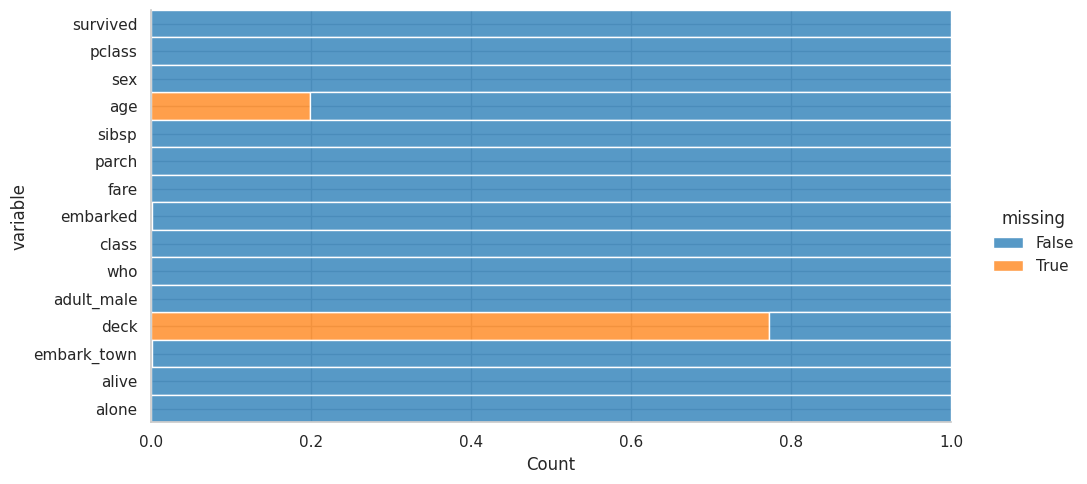

In [13]:
sns.displot(data=plot_null_titanic, y='variable', hue='missing', aspect=2, multiple='fill')

## I.08. VISUALIZACIÓN DE LOS VALORES NULOS EN EL CONJUNTO DE DATOS:

<Axes: >

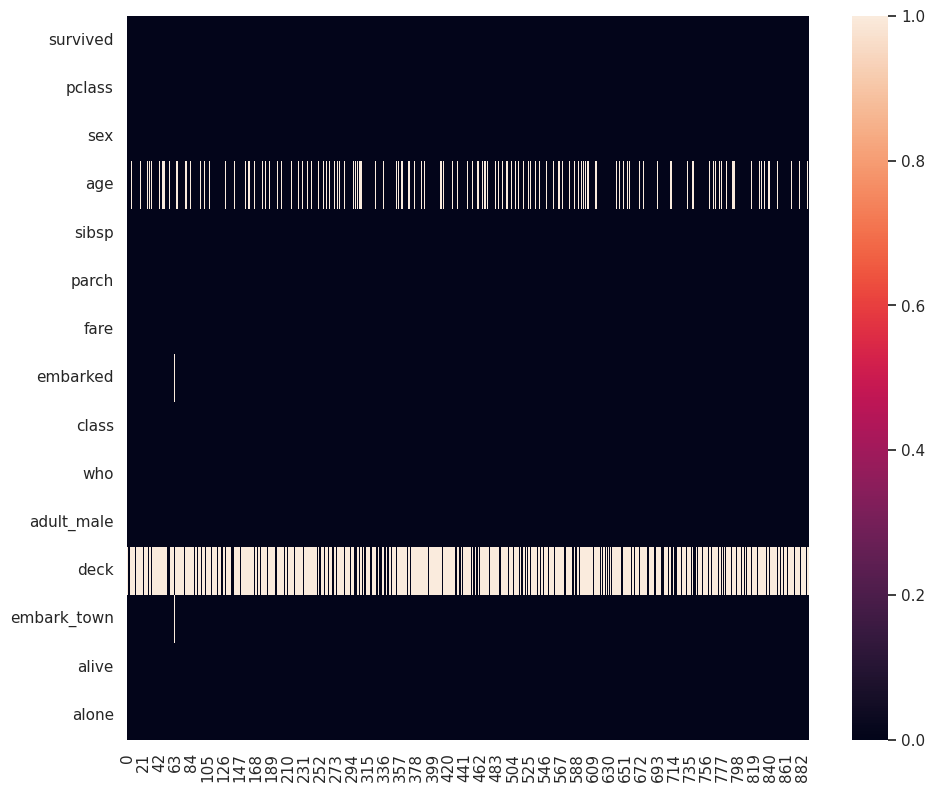

In [14]:
(
    titanic_df
    .isnull()
    .transpose()
    .pipe(
        lambda df: sns.heatmap(data=df)
    )
)

## I.09. CANTIDAD DE VALORES ELIMINADOS (NULOS):

In [15]:
processed_titanic_df = (
    titanic_df
    .dropna()
)
processed_titanic_df.shape

(182, 15)

In [16]:
titanic_df.shape[0] - processed_titanic_df.shape[0]

709

# II. CONTEOS

# II.01. CONTEO DE TODAS LAS VARIABLES

In [17]:
titanic_df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## II.02. CONTEO DE VARIABLES NUMERICAS

In [18]:
titanic_df.describe(include=[np.number])

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## II.03. CONTEO DE VARIABLES CATEGORICAS

In [19]:
titanic_df.describe(include=object)

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [20]:
(
    titanic_df
    .astype(
        {
            'sex' : 'category',
            'embarked' : 'category',
            'class' : 'category',
            'who' : 'category',
            'adult_male' : 'category',
            'deck' : 'category',
            'embark_town' : 'category',
            'alive' : 'category',
            'alone' : 'category'
        }
    )
).describe(include=['category', object])

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


## II.03. GRAFICOS DE CONTEO

<Axes: xlabel='embark_town'>

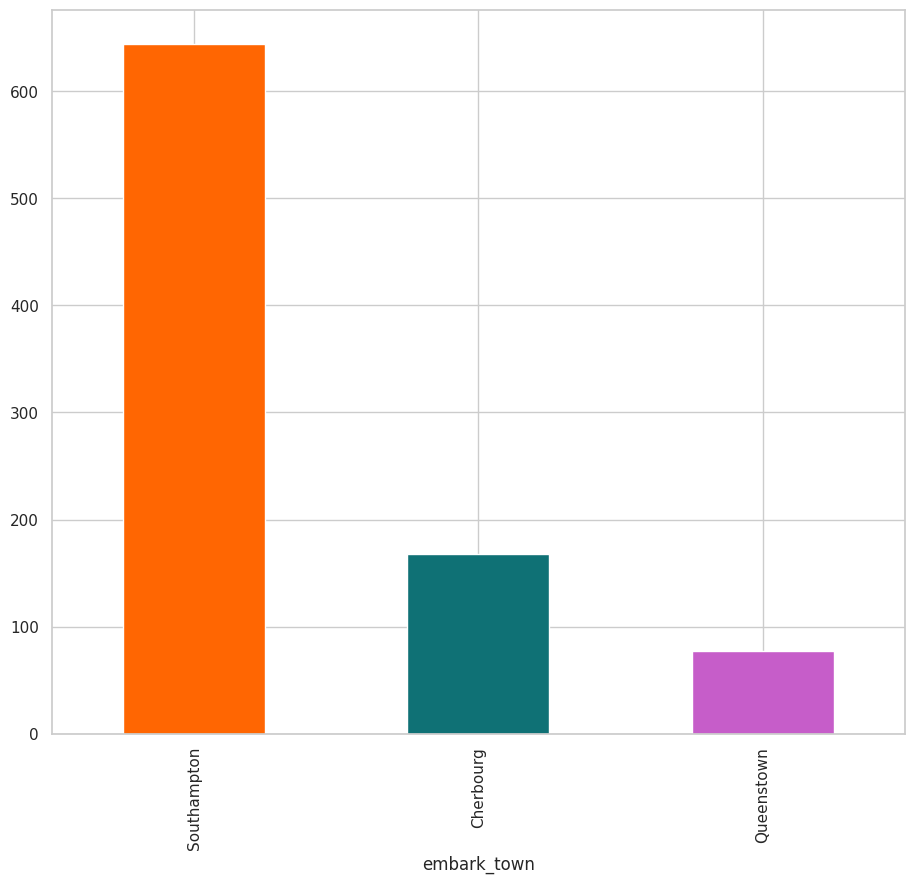

In [22]:
(
    titanic_df
    .embark_town
    .value_counts()
    .plot(
        kind='bar',
        color=penguin_color.values()
    )
)

In [27]:
embark_color = {
    'Southampton': '#ff6602ff',
    'Cherbourg': '#0f7175ff',
    'Queenstown': '#c65dc9ff'
}

<ipython-input-29-fce01c2003f3>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='embark_town', ylabel='count'>

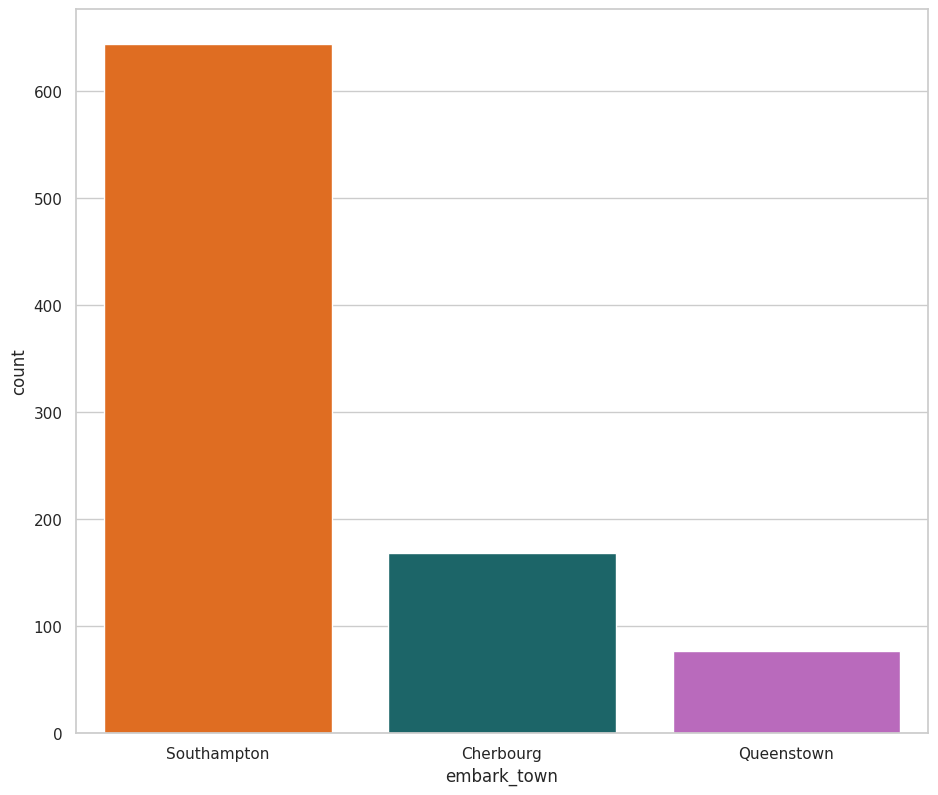

In [29]:
(
    titanic_df
    .value_counts('embark_town', sort=True)
    .reset_index(name='count')
    .pipe(
        lambda df: (
            sns.barplot(
                data=df,
                x='embark_town',
                y='count',
                palette=embark_color
            )
            )
        )
    )

# III. PROPORCIONES

In [31]:
titanic_df['variable'] = ''
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,variable
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,


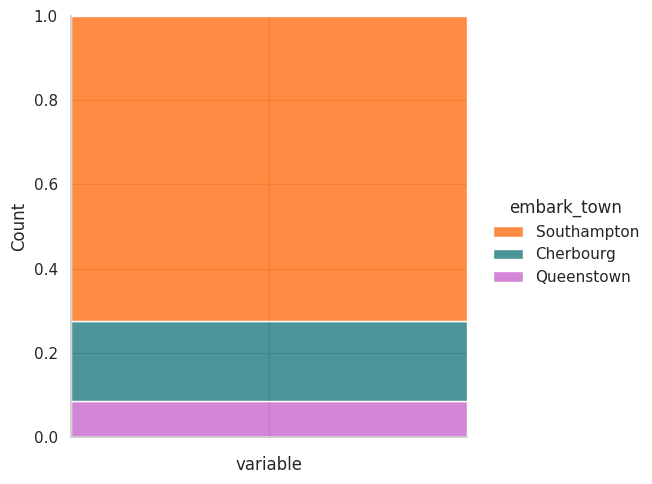

In [32]:
(
    titanic_df
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='variable',
                hue='embark_town',
                multiple='fill',
                palette=embark_color
            )
        )
    )
)